# The Correlation Coefficient

**Correlation** (a.k.a *Pearson correlation coefficient* or linear association) takes values between `-1` and `1`, indicatin the **1) strength and 2) direction** of the linear relationship between two variables. We denote the correlation by $r$.

Graphically, **it measures how clustered the scatter diagram is around a straight line**.

Figure 7.10 shows eight plots and their corresponding correlations.

- Only when the relationship is perfectly linear is the correlation either -1 or +1.
- If the relationship is strong and positive, the correlation will be near +1.
- If it is strong and negative, it will be near -1.
- If there is no apparent linear relationship between the variables, then the correlation will be near zero.

![](../assets/stats/correlation_coefficient.png)

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_context(
    "notebook",
    font_scale=1.5,
    rc={
        "lines.linewidth": 2.5
    }
)

In [3]:
path_data = Path('data/')

## Interactive: copy-modify-run

**Try**: call the function below with different values of `r` to generate data that fits that correlation coefficient.

In [4]:
# Source: https://inferentialthinking.com/chapters/15/1/correlation/
def r_scatter(r):
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    g = sns.relplot(x=x, y=y, kind='scatter', height=5)
    g.ax.set_xlim(-4, 4)
    g.ax.set_ylim(-4, 4)

Change the following value to see different outputs:

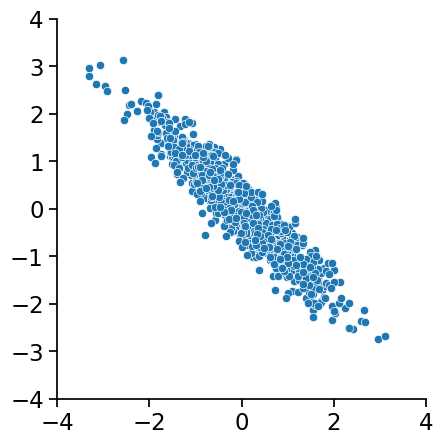

In [18]:
r_scatter(-0.94) # <<<--- CHANGE THIS (value between -1 and 1)

## Definition: Math

The formula for correlation is:

$$
r = \frac{1}{n-1} \sum_{i=1}^{n} \left( \frac{x_i-\bar{x}}{s_x} \right) \left( \frac{y_i-\bar{y}}{s_y} \right)
$$

The terms inside the parentheses are exactly the definitions of $z$-scores for $x$ and $y$:

$$
\begin{align*}
z_{x,i} &= \frac{x_i-\bar{x}}{s_x} \\
z_{y,i} &= \frac{y_i-\bar{y}}{s_y}
\end{align*}
$$

So, the formula simplifies to:

$$
r = \frac{\sum z_x z_y}{n-1}
$$

In essence, **correlation $r$ is the average of the products of the two variables, when both variables are measured in standard units.**

## Definition: Code

Hence we can define $r$ in two Python functions as follows:


In [ ]:
def z_score(nums: np.ndarray) -> np.ndarray:
    z = (nums - np.mean(nums)) / np.std(nums)
    return z

In [ ]:
def correlation(df: pd.DataFrame, x: str, y: str) -> float:
    z_x = z_score(df[x])
    z_y = z_score(df[y])
    return np.mean(z_x * z_y)

## Correlation Coefficient is Unitless

One important aspect of the correlation is that it’s unitless (since it is a product of two untiless quantities). The following figure shows the relationship between weights and heights of `507` physically active individuals:

![](../assets/stats/correlation_unitless.png)

- Figure a: weight is measured in kilograms (`kg`) and height in centimeters (`cm`).
- Figure b: weight has been converted to pounds (`lbs`) and height to inches (`in`)

## Correlation Measures *Linear* Association Only

Correlation measures only one kind of association – linear. Variables that have strong non-linear association might have very low correlation. Here is an example of variables that have a perfect quadratic relation $y = x^2$ but have correlation equal to 0.

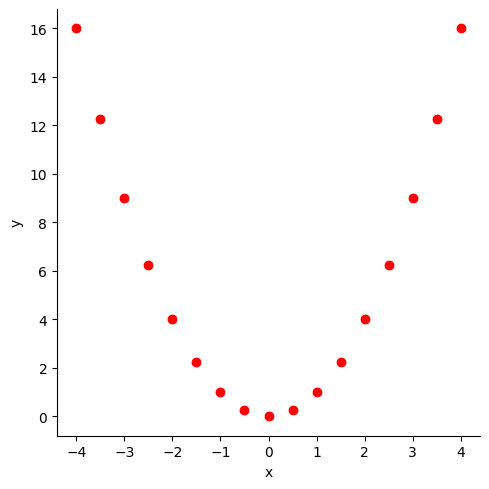

In [ ]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = pd.DataFrame({'x': new_x, 'y': new_x**2})
g = sns.relplot(
    data=nonlinear,
    x='x', y='y',
    kind='scatter',
    s=60, color='r',
    height=5,
)

In [ ]:
correlation(nonlinear, 'x', 'y')

np.float64(0.0)

## Example: Hybrid Cars Dataset

In [6]:
hybrid = pd.read_csv(path_data / 'hybrid.csv')
hybrid

,vehicle,year,msrp,acceleration,mpg,class
0,Prius (1st Gen),1997,24509.74,7.46,41.26,Compact
1,Tino,2000,35354.97,8.20,54.10,Compact
2,Prius (2nd Gen),2000,26832.25,7.97,45.23,Compact
3,Insight,2000,18936.41,9.52,53.00,Two Seater
4,Civic (1st Gen),2001,25833.38,7.04,47.04,Compact
...,...,...,...,...,...,...
148,S400,2013,92350.00,13.89,21.00,Large
149,Prius Plug-in,2013,32000.00,9.17,50.00,Midsize
150,C-Max Energi Plug-in,2013,32950.00,11.76,43.00,Midsize
151,Fusion Energi Plug-in,2013,38700.00,11.76,43.00,Midsize


The table `hybrid` contains data on hybrid passenger cars sold in the United States from 1997 to 2013. The data were adapted from the online data archive of [Prof. Larry Winner](http://www.stat.ufl.edu/%7Ewinner/) of the University of Florida. The columns:

- `vehicle`: model of the car
- `year`: year of manufacture
- `msrp`: manufacturer's suggested retail price in 2013 dollars
- `acceleration`: acceleration rate in km per hour per second
- `mpg`: fuel econonmy in miles per gallon
- `class`: the model's class.

### Relationship 1: Price vs. Acceleration

The graph below is a **scatter plot** of `msrp` *versus* `acceleration`. That means:

- `msrp` is plotted on the vertical axis
- `accelaration` on the horizontal

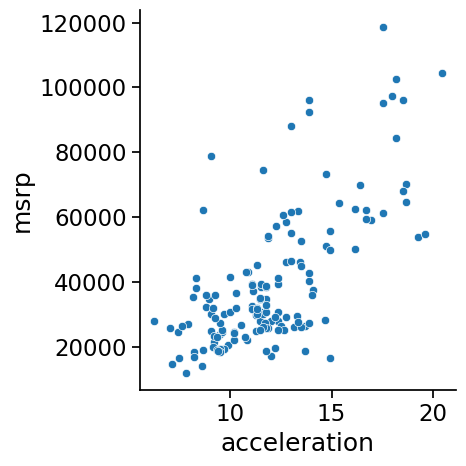

In [7]:
sns.relplot(
    data=hybrid, x='acceleration', y='msrp',
    kind='scatter',
    height=5,
);

**Notice the positive association**. The scatter of points is **sloping upwards**, indicating that cars with greater acceleration tended to cost more, on average; conversely, the cars that cost more tended to have greater acceleration on average. 

The `lmplot` can actuall draw a *Regression Line* making it easier to see the relationship between the two numerical variables:

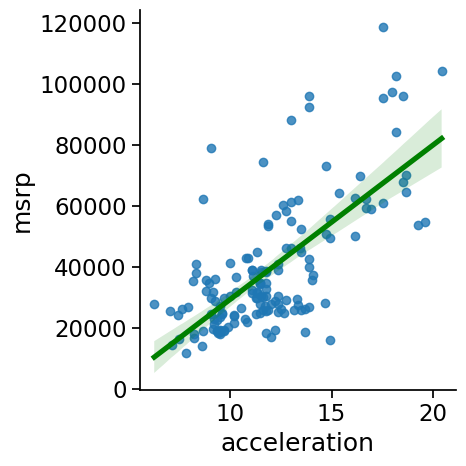

In [8]:
sns.lmplot(
    data=hybrid, x='acceleration', y='msrp',
    height=5,
    line_kws={'color': 'green'}
);

- Question: **What is the shaded region around the line?**
- Answer: **Confidence Interval (CI)**. The further away the line is from the dataset, the narrow the shaded region is, indicating less certainty. (Discussion of CI is out of scope)

### Relationship 2: Price vs Efficiency

The scatter diagram of MSRP versus mileage shows **a negative association**. Hybrid cars with higher mileage tended to cost less, on average. This seems surprising till you consider that **cars that accelerate fast tend to be less fuel efficient and have lower mileage**. As the previous scatter plot showed, those were also the cars that tended to cost more. 

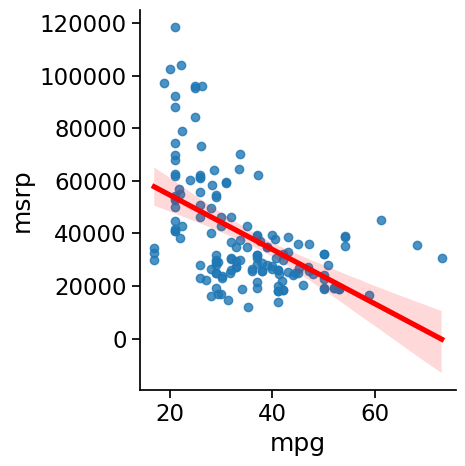

In [9]:
sns.lmplot(
    data=hybrid, x='mpg', y='msrp',
    height=5,
    line_kws={'color': 'red'}
);

Along with the negative association, the scatter diagram of price versus efficiency shows a non-linear relation between the two variables. The points appear to be clustered around a curve, **not around a straight line**. 

### Relationship 3: Price vs Efficiency (SUV)

**If we restrict the data just to the SUV class**, however, the association between price and efficiency is still **negative but the relation appears to be more linear**.

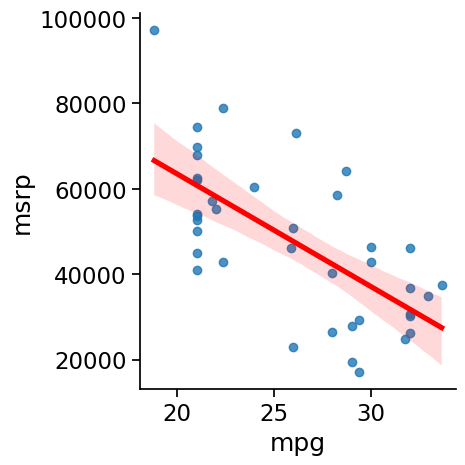

In [10]:
suv = hybrid[hybrid['class'] == 'SUV'].copy()

sns.lmplot(
    data=suv, x='mpg', y='msrp',
    height=5,
    line_kws={'color': 'red'}
);

### Relationship 4: Price vs Acceleration (SUV)

The relation between the price and acceleration of SUV's also shows a **linear trend, but with a positive slope**.

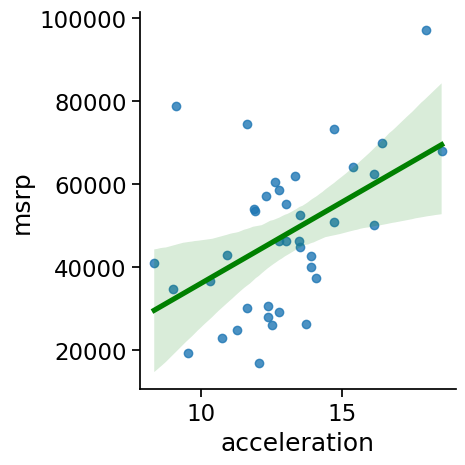

In [11]:
sns.lmplot(
    data=suv, x='acceleration', y='msrp',
    height=5,
    line_kws={'color': 'green'}
);

## Application on the Hybrid Cars Dataset

In [12]:
rel1_corr, _ = stats.pearsonr(hybrid['acceleration'], hybrid['msrp'])
rel2_corr, _ = stats.pearsonr(hybrid['mpg'], hybrid['msrp'])
rel3_corr, _ = stats.pearsonr(suv['mpg'], suv['msrp'])
rel4_corr, _ = stats.pearsonr(suv['acceleration'], suv['msrp'])

Let's lay down all the plots from above, and show their correlation as text on the plot:

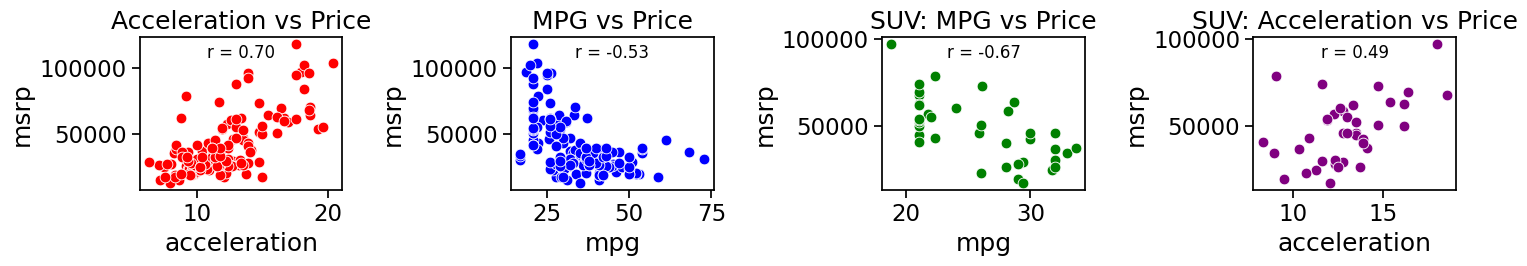

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 3))

# Relationship 1: Price vs. Acceleration (Hybrid)
sns.scatterplot(x='acceleration', y='msrp', data=hybrid, s=60, color='red', ax=ax[0])
ax[0].set_title('Acceleration vs Price')
ax[0].text(0.5, 0.9, f'r = {rel1_corr:.2f}', ha='center', va='center', 
           transform=ax[0].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 2: Price vs Efficiency (Hybrid)
sns.scatterplot(x='mpg', y='msrp', data=hybrid, s=60, color='blue', ax=ax[1])
ax[1].set_title('MPG vs Price')
ax[1].text(0.5, 0.9, f'r = {rel2_corr:.2f}', ha='center', va='center', 
           transform=ax[1].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 3: Price vs Efficiency (SUV)
sns.scatterplot(x='mpg', y='msrp', data=suv, s=60, color='green', ax=ax[2])
ax[2].set_title('SUV: MPG vs Price')
ax[2].text(0.5, 0.9, f'r = {rel3_corr:.2f}', ha='center', va='center', 
           transform=ax[2].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 4: Price vs Acceleration (SUV)
sns.scatterplot(x='acceleration', y='msrp', data=suv, s=60, color='purple', ax=ax[3])
ax[3].set_title('SUV: Acceleration vs Price')
ax[3].text(0.5, 0.9, f'r = {rel4_corr:.2f}', ha='center', va='center', 
           transform=ax[3].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


plt.tight_layout()
plt.show()

These values confirm what we had observed: 

- There is a **negative** association between price and efficiency, whereas the association between price and acceleration is **positive**.
- The linear relation between price and acceleration is a **little weaker** (correlation about `0.5`) **than between** price and mileage (correlation about `-0.67`). 

### `sns.pairplot`

Plot pairwise relationships in a dataset:

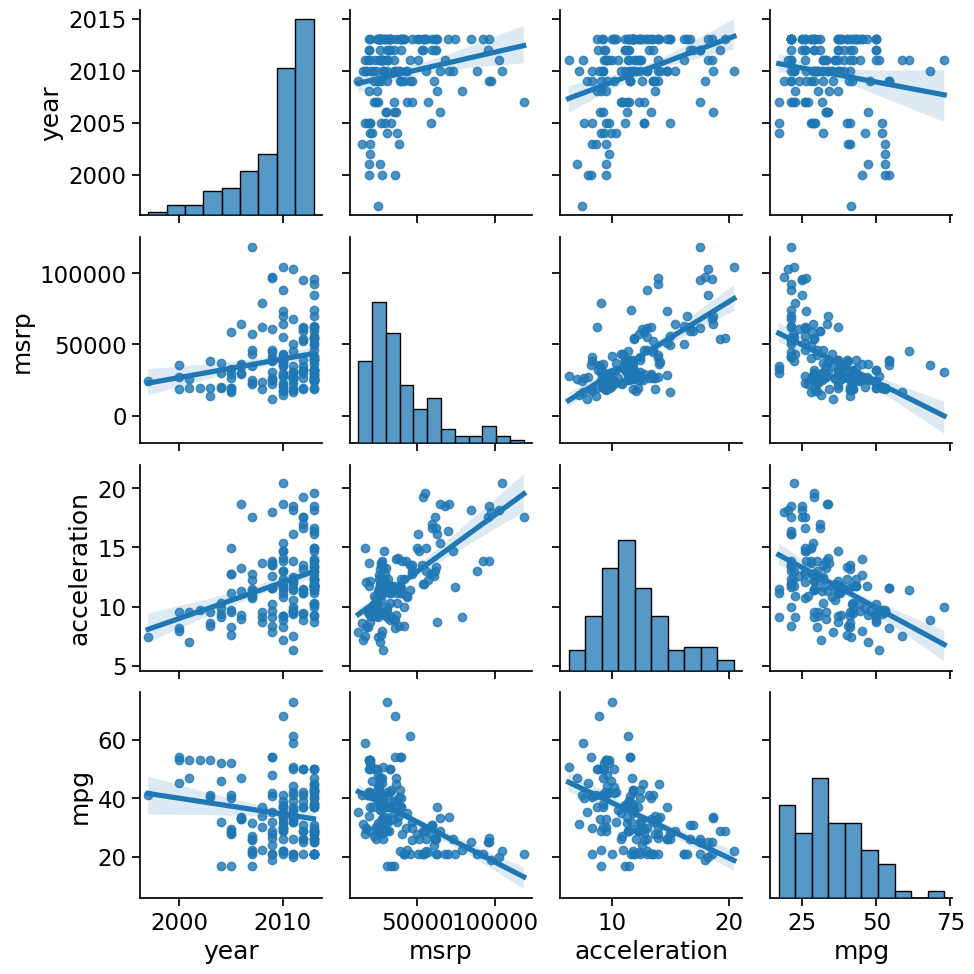

In [14]:
sns.pairplot(hybrid, kind='reg')

By default, this function will create a grid of Axes such that each numeric variable in `data` will by shared across the y-axes across a single row and the x-axes across a single column.

The diagonal plots are treated differently: a univariate distribution plot is drawn to show the marginal distribution of the data in each column.